# 🛒 Identification of Promising E-Commerce Acquisition Targets
### Data-Driven Seller Evaluation for Strategic Acquisition

---

**Author:** Sireesha Ragipati  
**Dataset:** Sample Longlist — Amazon Marketplace Seller Data  
**Goal:** Identify high-potential e-commerce sellers worth acquiring based on product volume, ratings, brand strength, and market presence

---

## 📌 Business Context

E-commerce acquisition firms evaluate hundreds of Amazon sellers to identify the best candidates for purchase. A promising acquisition target should have:

- **High product volume** — broad catalog with strong market presence
- **Strong seller reputation** — high positive ratings, low negative feedback
- **Engaged customer base** — large number of total ratings (proxy for sales volume)
- **Multi-brand portfolio** — diversified revenue, not single-product risk
- **Hero products** — at least one or two top-performing flagship products

### Analysis Workflow

```
Raw Seller Data
     ↓
Data Cleaning & Feature Extraction
     ↓
Data Quality Filtering (remove empty/invalid sellers)
     ↓
Exploratory Data Analysis
     ↓
Acquisition Scoring Model
     ↓
Top Seller Identification + Visualizations
```

---
## 📦 Step 1: Import Libraries & Load Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']

# Load data
df = pd.read_excel("Sample_Longlist_Data.xlsx")

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(1)

✅ Dataset loaded: 1839 rows × 18 columns


,Date Added,category,sellerlink,sellerlink-url,sellerstorefront-url,sellerproductcount,sellerratings,sellerdetails,seller business name,businessaddress,Count of seller brands,Max % of negative seller ratings - last 30 days,Max % of negative seller ratings - last 90 days,Max % of negative seller ratings - last 12 months,Hero Product 1 #ratings,Hero Product 2 #ratings,Sample brand name,Sample Brand URL
0,2020-11-15,Garden,Seller 1,Seller 1-link,Seller 1-storefrontlink,"1-16 of over 100,000 results",88% positive in the last 12 months (118 ratings),Lohas Living Inc James Mazzello US 845 3RD Ave...,Business Name:Lohas Living Inc,411 THEODORE FREMD AVESTE 206 SOUTHRyeNY10580-...,16,17,11,12,5873,4957,Visit the YAMAZAKI Store,https://www.amazon.de/-/en/stores/YAMAZAKI/pag...


In [3]:
print("📋 Dataset Info:")
df.info()
print(f"\n🔍 Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1839 entries, 0 to 1838
Data columns (total 18 columns):
 #   Column                                             Non-Null Count  Dtype         
---  ------                                             --------------  -----         
 0   Date Added                                         1839 non-null   datetime64[ns]
 1   category                                           1839 non-null   object        
 2   sellerlink                                         1839 non-null   object        
 3   sellerlink-url                                     1839 non-null   object        
 4   sellerstorefront-url                               1839 non-null   object        
 5   sellerproductcount                                 1513 non-null   object        
 6   sellerratings                                      1411 non-null   object        
 7   sellerdetails                                      1812 non-null   object        
 8   se

---
## 🧹 Step 2: Data Cleaning & Feature Extraction

### Column Audit

| Column | Action | Reason |
|--------|--------|--------|
| `Date Added` | ❌ Drop | All rows have same date (2020-11-15) — zero variation |
| `category` | ❌ Drop | All rows in same category (Garden) — no variation |
| `sellerlink`, `sellerlink-url`, `sellerstorefront-url` | ❌ Drop | Not real URLs — unusable for scraping |
| `sellerproductcount` | 🔧 Extract → `product_count` | Extract numeric count from text |
| `sellerratings` | 🔧 Extract → `positive_rating %`, `total_ratings` | Parse structured text |
| `sellerdetails` | 🔧 Extract → `Phone`, `Email` | Contact info for outreach |
| `seller business name` | 🔧 Extract → `business_name` | Clean name for reporting |
| `businessaddress` | 🔧 Extract → `Country` | Country for geographic filtering |

In [4]:
# --- Date Added: all same date, no value ---
print(f"Unique dates in 'Date Added': {df['Date Added'].nunique()}")
# All 2020-11-15 → drop

# --- Category: all same ---
print(f"Unique categories: {df['category'].nunique()} → {df['category'].unique()}")

Unique dates in 'Date Added': 1
Unique categories: 1 → ['Garden']


In [5]:
# Extract product count from text like 'over 1,234 products'
df['product_count'] = (
    df['sellerproductcount']
    .str.extract(r'over ([\d,]+)')[0]
    .str.replace(',', '')
    .astype(float)
)

print("Product Count (sample):")
print(df[['sellerproductcount', 'product_count']].dropna().head(5))

Product Count (sample):
             sellerproductcount  product_count
0  1-16 of over 100,000 results       100000.0
2    1-16 of over 2,000 results         2000.0
4    1-16 of over 1,000 results         1000.0
6    1-16 of over 4,000 results         4000.0
7    1-16 of over 3,000 results         3000.0


In [6]:
# Extract positive rating % and total ratings from text
# Example: '95% positive ratings (1,234 ratings)'
pattern = r'(\d+)% positive.*\((\d+) ratings\)'
df[['positive_rating in percentage', 'total_ratings given']] = (
    df['sellerratings']
    .str.extract(pattern)
    .astype(float)
)

# Derive negative count: total - positive
df['negative_count'] = df['total_ratings given'] - (
    df['total_ratings given'] * df['positive_rating in percentage'] / 100
).round()

print("Ratings extraction sample:")
print(df[['sellerratings', 'positive_rating in percentage', 'total_ratings given', 'negative_count']].dropna().head(3))

Ratings extraction sample:
                                      sellerratings  \
0  88% positive in the last 12 months (118 ratings)   
1  90% positive in the last 12 months (566 ratings)   
2   85% positive in the last 12 months (75 ratings)   

   positive_rating in percentage  total_ratings given  negative_count  
0                           88.0                118.0            14.0  
1                           90.0                566.0            57.0  
2                           85.0                 75.0            11.0  


In [7]:
# Check discrepancy between extracted negative ratings vs existing column
print("Discrepancy Check — Max % Negative (12m) vs extracted:")
print(df[['Max % of negative seller ratings - last 12 months', 'sellerratings']].head(5))

Discrepancy Check — Max % Negative (12m) vs extracted:
   Max % of negative seller ratings - last 12 months  \
0                                                 12   
1                                                  9   
2                                                 12   
3                                                  0   
4                                                 15   

                                      sellerratings  
0  88% positive in the last 12 months (118 ratings)  
1  90% positive in the last 12 months (566 ratings)  
2   85% positive in the last 12 months (75 ratings)  
3                                               NaN  
4   81% positive in the last 12 months (52 ratings)  


> **⚠️ Data Quality Note:** There is a discrepancy between the `Max % of negative seller ratings - last 12 months` column and the extracted ratings from `sellerratings`. The existing columns represent time-windowed snapshots (30 days, 90 days, 12 months), which may differ from the extracted lifetime percentage. We will keep the pre-existing windowed columns as they are more granular and recent.

In [8]:
# Extract contact information from sellerdetails column
df['sellerdetails'] = df['sellerdetails'].fillna('')

df['Phone_Number'] = df['sellerdetails'].str.extract(r'(\+?[\d\s\-]{7,15})')
df['Email'] = df['sellerdetails'].str.extract(r'([\w.+-]+@[\w-]+\.[\w.]+)')

print(f"Sellers with phone: {df['Phone_Number'].notna().sum()}")
print(f"Sellers with email: {df['Email'].notna().sum()}")

Sellers with phone: 367
Sellers with email: 323


In [9]:
# Extract clean business name
pattern = r'Business Name:([^\d\n]+)'
df['business_name'] = df['seller business name'].str.extract(pattern)
df['business_name'] = df['business_name'].str.strip()

# Clean sample brand name
df['Sample brand name'] = df['Sample brand name'].str.replace(r'Visit the |\sStore', '', regex=True)

print("Business name sample:")
print(df[['seller business name', 'business_name']].dropna().head(3))

Business name sample:
                                seller business name  \
0                     Business Name:Lohas Living Inc   
2  Business Name:nantongaohuanfangzhipinyouxiango...   
3   Business Name:Zhengzhou Yaoqiong Trading Company   

                          business_name  
0                      Lohas Living Inc  
2  nantongaohuanfangzhipinyouxiangongsi  
3    Zhengzhou Yaoqiong Trading Company  


In [10]:
# Extract country from business address
def extract_country(address):
    if pd.isna(address) or address == '':
        return 'Unknown'
    parts = str(address).split(',')
    return parts[-1].strip() if parts else 'Unknown'

df['Country'] = df['businessaddress'].apply(extract_country)

print("Country distribution:")
print(df['Country'].value_counts().head(10))

Country distribution:
Country
Unknown                                                                                                75
xinjiangxianwananzhenximacuncunxinanyunchengshanxi043100CN                                              2
411 THEODORE FREMD AVESTE 206 SOUTHRyeNY10580-1410US                                                    1
LiShiQuBingHeNanDongLu(WangLeDongZiYouMenMianFang)LvLiangShanXi033000CN                                 1
puyuanzhenyangmaoshanshichangzhongyangshangcheng1-120haojiaxingshitongxiangshizhejiangsheng314502CN     1
DanChengXianHuJiXiangFanLouCunzhoukoucityChina477193CN                                                  1
fukanglufukangyuanBzuo802yulinshiyuyangqushanxisheng719000CN                                            1
XiaoDianQuPingYangLu65HaoPingYangJingYuan6haoLou8Ceng805ShiTaiYuanShiShanXiSheng030006CN                1
JiaxianwangjixiangSiliyingcun7haoPingdingshanshiHenansheng467100CN                                      1
xiangchengshifan

In [11]:
# Remove Chinese sellers (CN) — not relevant for this acquisition focus
cn_count = len(df[df['Country'] == 'CN'])
df = df[df['Country'] != 'CN'].reset_index(drop=True)

print(f"Removed {cn_count} Chinese sellers.")
print(f"Remaining sellers: {len(df)}")

Removed 0 Chinese sellers.
Remaining sellers: 1839


In [12]:
# Average hero product ratings (flagship product performance)
df['avg_hero_products'] = df[['Hero Product 1 #ratings', 'Hero Product 2 #ratings']].mean(axis=1)

print("Hero product rating stats:")
print(df['avg_hero_products'].describe())

Hero product rating stats:
count     1839.000000
mean      1082.459489
std       4906.589551
min          0.000000
25%          0.000000
50%          2.000000
75%        141.500000
max      74223.000000
Name: avg_hero_products, dtype: float64


In [13]:
# Drop original raw columns (replaced by extracted features)
cols_to_drop_1 = [
    'Date Added', 'category', 'sellerlink', 'sellerproductcount',
    'sellerratings', 'seller business name', 'Sample brand name'
]
# Note: keeping Sample brand name and business_name after cleaning
cols_to_drop_2 = [
    'sellerlink-url', 'sellerstorefront-url', 'sellerdetails',
    'businessaddress', 'Phone_Number', 'Email', 'business_name'
]

df.drop(columns=cols_to_drop_1 + cols_to_drop_2, axis=1, inplace=True, errors='ignore')

print(f"✅ Dataset after dropping raw columns: {df.shape}")
print(f"   Remaining columns: {list(df.columns)}")

✅ Dataset after dropping raw columns: (1839, 13)
   Remaining columns: ['Count of seller brands', 'Max % of negative seller ratings - last 30 days', 'Max % of negative seller ratings - last 90 days', 'Max % of negative seller ratings - last 12 months', 'Hero Product 1 #ratings', 'Hero Product 2 #ratings', 'Sample Brand URL', 'product_count', 'positive_rating in percentage', 'total_ratings given', 'negative_count', 'Country', 'avg_hero_products']


---
## 🔍 Step 3: Data Quality Filtering

We remove sellers that are clearly inactive or have no data — they cannot be evaluated and would skew our analysis.

### Filter Rules

| Rule | Logic | Reason |
|------|-------|--------|
| **Filter 1** | `brand_count=0` AND all key metrics = 0 or null | Ghost sellers — no products, no ratings, no activity |
| **Filter 2** | `brand_count=0` AND `product_count=null` AND `avg_hero=0` | No brands, no products, no hero items |
| **Filter 3** | `total_ratings=null` AND `product_count=null` | No activity signals at all |

In [14]:
# Filter 1: Sellers with 0 brands AND all key metrics are 0/null
mask_f1 = (
    (df['Count of seller brands'] == 0) &
    (
        df[['product_count', 'positive_rating in percentage',
            'total_ratings given', 'avg_hero_products']].isna().all(axis=1) |
        df[['product_count', 'positive_rating in percentage',
            'total_ratings given', 'avg_hero_products']].eq(0).all(axis=1)
    )
)

print(f"Filter 1 — Ghost sellers (0 brands, all metrics empty): {mask_f1.sum()} rows")

Filter 1 — Ghost sellers (0 brands, all metrics empty): 0 rows


In [15]:
# Filter 2: 0 brands, null product count, 0 hero product ratings
mask_f2 = (
    (df[['Count of seller brands', 'avg_hero_products']].eq(0).all(axis=1)) &
    (df['product_count'].isnull())
)

print(f"Filter 2 — No brands, no products, no hero items: {mask_f2.sum()} rows")

# Apply both filters together
combined_mask = mask_f1 | mask_f2
rows_before = len(df)
df = df[~combined_mask].reset_index(drop=True)

print(f"\nRows removed by filters 1+2: {rows_before - len(df)}")
print(f"Dataset after filtering: {df.shape}")

Filter 2 — No brands, no products, no hero items: 330 rows

Rows removed by filters 1+2: 330
Dataset after filtering: (1509, 13)


In [16]:
print("Remaining missing values:")
nulls = df.isnull().sum()
print(nulls[nulls > 0])

print(f"\n💡 Note: Remaining NaN values are NOT filled.")
print("   Reason: Imputing missing product counts or ratings with 0 or mean")
print("   would create misleading signals for acquisition scoring.")
print("   These rows will be excluded only when relevant metrics are needed.")

Remaining missing values:
product_count                    471
positive_rating in percentage    915
total_ratings given              915
negative_count                   915
dtype: int64

💡 Note: Remaining NaN values are NOT filled.
   Reason: Imputing missing product counts or ratings with 0 or mean
   would create misleading signals for acquisition scoring.
   These rows will be excluded only when relevant metrics are needed.


---
## 📊 Step 4: Exploratory Data Analysis

Understanding the dataset before building the scoring model.

In [17]:
# Dataset overview stats
print("📈 Key Dataset Statistics:")
print("=" * 50)

stats = {
    'Total sellers': len(df),
    'Sellers with product data': df['product_count'].notna().sum(),
    'Sellers with ratings': df['total_ratings given'].notna().sum(),
    'Multi-brand sellers (>1 brand)': (df['Count of seller brands'] > 1).sum(),
    'Perfect 100% positive rating': (df['positive_rating in percentage'] == 100).sum(),
    'Avg product count': f"{df['product_count'].mean():.0f}",
    'Avg positive rating %': f"{df['positive_rating in percentage'].mean():.1f}%",
    'Countries represented': df['Country'].nunique()
}

for k, v in stats.items():
    print(f"  {k:<40}: {v}")

📈 Key Dataset Statistics:
  Total sellers                           : 1509
  Sellers with product data               : 1038
  Sellers with ratings                    : 594
  Multi-brand sellers (>1 brand)          : 1329
  Perfect 100% positive rating            : 47
  Avg product count                       : 8783
  Avg positive rating %                   : 88.0%
  Countries represented                   : 1465


### 4.1 Seller Distribution by Country

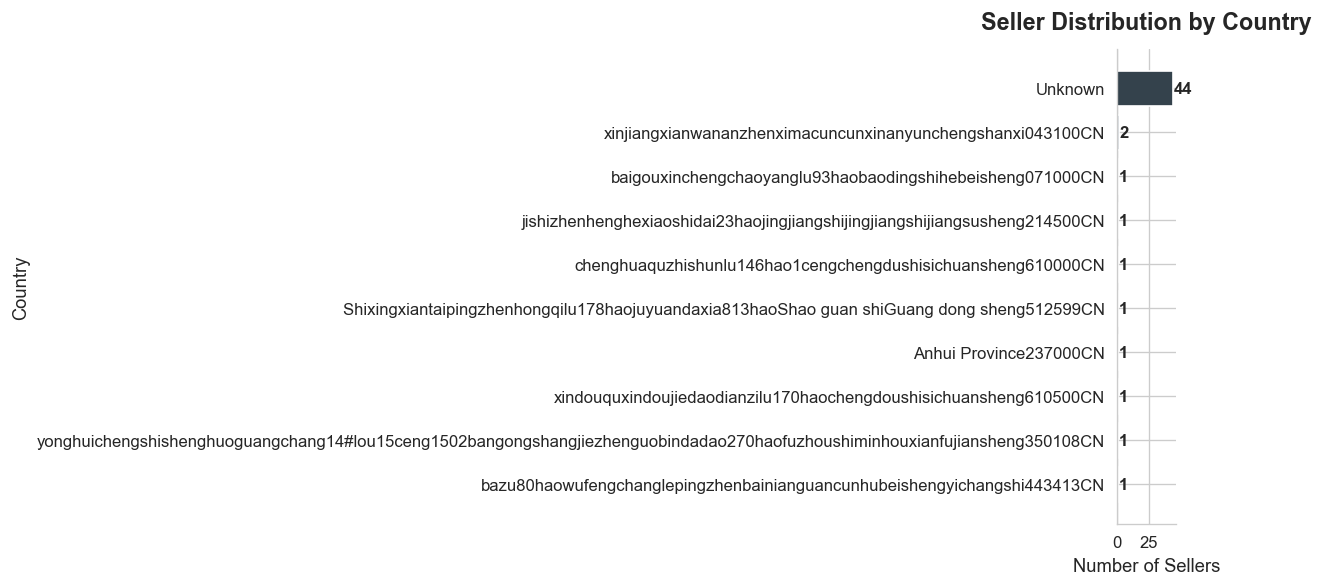


Top country: Unknown with 44 sellers (2.9%)


In [18]:
country_counts = df['Country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1],
               color=sns.color_palette('Blues_d', len(country_counts)))

for bar, val in zip(bars, country_counts.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Seller Distribution by Country', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Sellers', fontsize=11)
ax.set_ylabel('Country', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nTop country: {country_counts.index[0]} with {country_counts.values[0]} sellers ({country_counts.values[0]/len(df)*100:.1f}%)")

### 4.2 Distribution of Seller Positive Ratings

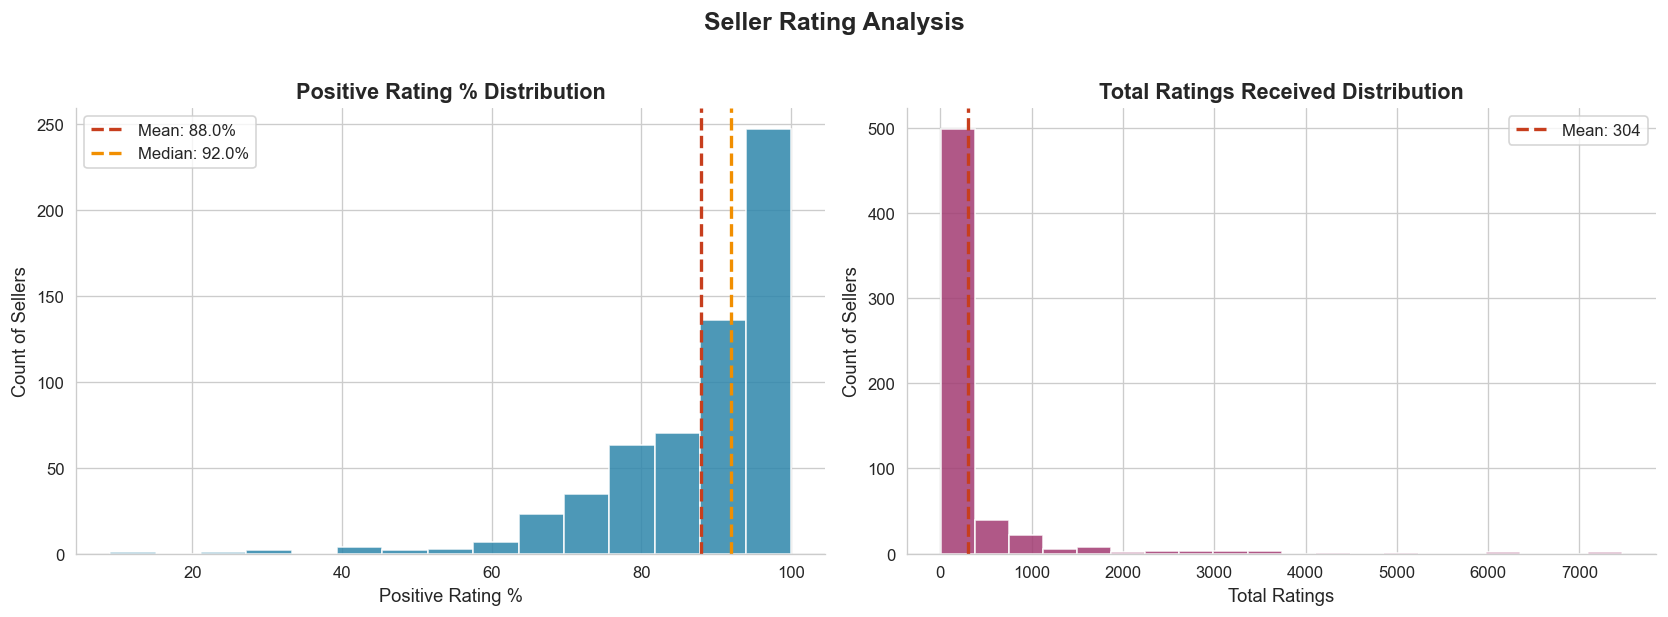


Insight: 350 sellers (58.9%) have ≥90% positive ratings


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of positive rating %
ax1 = axes[0]
ratings_data = df['positive_rating in percentage'].dropna()
ax1.hist(ratings_data, bins=15, color='#2E86AB', edgecolor='white', alpha=0.85)
ax1.axvline(ratings_data.mean(), color='#C73E1D', linestyle='--', linewidth=2,
            label=f'Mean: {ratings_data.mean():.1f}%')
ax1.axvline(ratings_data.median(), color='#F18F01', linestyle='--', linewidth=2,
            label=f'Median: {ratings_data.median():.1f}%')
ax1.set_title('Positive Rating % Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Positive Rating %', fontsize=11)
ax1.set_ylabel('Count of Sellers', fontsize=11)
ax1.legend(fontsize=10)
ax1.spines[['top', 'right']].set_visible(False)

# Histogram of total ratings
ax2 = axes[1]
total_data = df['total_ratings given'].dropna()
ax2.hist(total_data, bins=20, color='#A23B72', edgecolor='white', alpha=0.85)
ax2.axvline(total_data.mean(), color='#C73E1D', linestyle='--', linewidth=2,
            label=f'Mean: {total_data.mean():.0f}')
ax2.set_title('Total Ratings Received Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Total Ratings', fontsize=11)
ax2.set_ylabel('Count of Sellers', fontsize=11)
ax2.legend(fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Seller Rating Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nInsight: {(ratings_data >= 90).sum()} sellers ({(ratings_data >= 90).mean()*100:.1f}%) have ≥90% positive ratings")

### 4.3 Negative Rating Trends: 30d vs 90d vs 12m

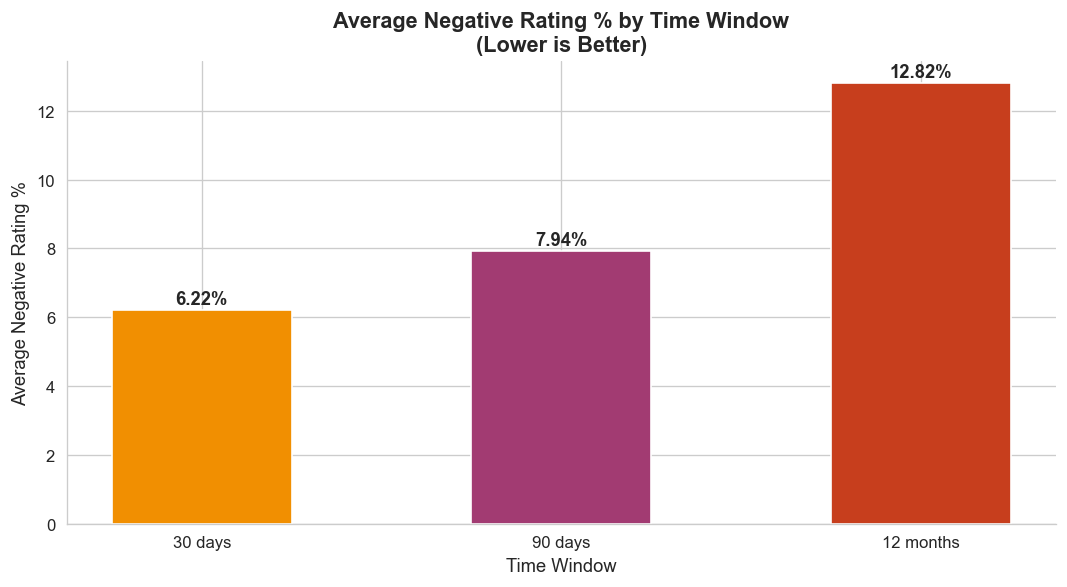


Insight: Negative ratings increase over longer time windows,
  indicating {'cumulative poor performance' if neg_means.values[-1] > neg_means.values[0] else 'improving seller quality'}.


In [20]:
neg_cols = [
    'Max % of negative seller ratings - last 30 days',
    'Max % of negative seller ratings - last 90 days',
    'Max % of negative seller ratings - last 12 months'
]

neg_means = df[neg_cols].mean()
labels = ['30 days', '90 days', '12 months']

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#F18F01', '#A23B72', '#C73E1D']
bars = ax.bar(labels, neg_means.values, color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, neg_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Average Negative Rating % by Time Window\n(Lower is Better)', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Negative Rating %', fontsize=11)
ax.set_xlabel('Time Window', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nInsight: Negative ratings {'increase' if neg_means.values[-1] > neg_means.values[0] else 'decrease'} over longer time windows,")
print("  indicating {'cumulative poor performance' if neg_means.values[-1] > neg_means.values[0] else 'improving seller quality'}.")

### 4.4 Product Count vs Total Ratings (Market Presence)

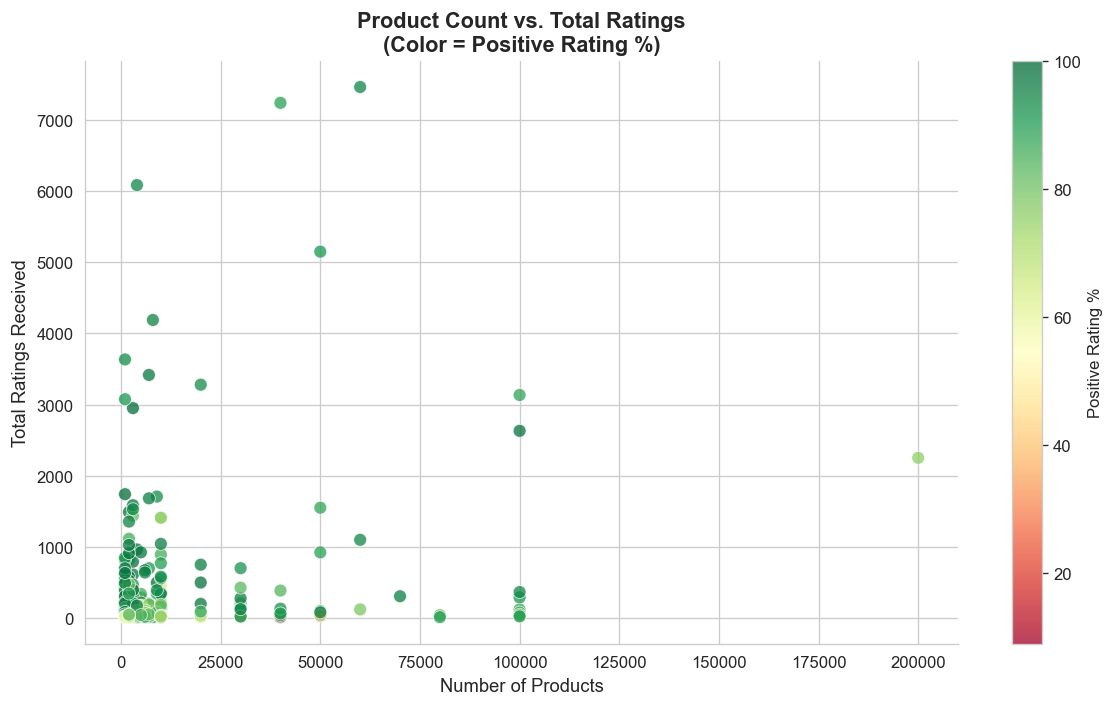


Correlation — Product Count vs Total Ratings: 0.229
Insight: Positive correlation — sellers with more products tend to have more ratings (more customers)


In [21]:
plot_df = df.dropna(subset=['product_count', 'total_ratings given', 'positive_rating in percentage'])

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    plot_df['product_count'],
    plot_df['total_ratings given'],
    c=plot_df['positive_rating in percentage'],
    cmap='RdYlGn',
    s=60, alpha=0.75, edgecolors='white', linewidth=0.5
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Positive Rating %', fontsize=10)

ax.set_title('Product Count vs. Total Ratings\n(Color = Positive Rating %)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Products', fontsize=11)
ax.set_ylabel('Total Ratings Received', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

corr = plot_df['product_count'].corr(plot_df['total_ratings given'])
print(f"\nCorrelation — Product Count vs Total Ratings: {corr:.3f}")
print(f"Insight: {'Positive' if corr > 0 else 'Negative'} correlation — sellers with more products tend to {'have more ratings (more customers)' if corr > 0 else 'have fewer ratings'}")

### 4.5 Top 10 Brands by Average Positive Rating

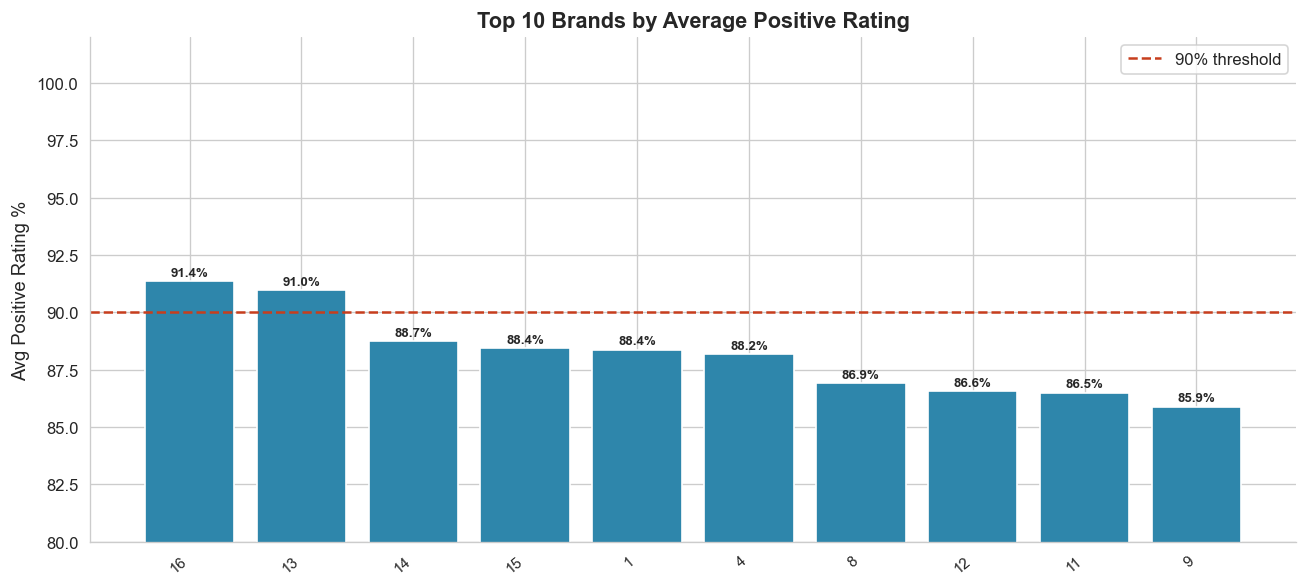

In [22]:
brand_col = [c for c in df.columns if 'brand name' in c.lower() or 'brand' in c.lower()]
brand_col = brand_col[0] if brand_col else None

if brand_col:
    top_brands = (
        df.groupby(brand_col)['positive_rating in percentage']
        .mean()
        .dropna()
        .sort_values(ascending=False)
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = ['#2E86AB' if v < 100 else '#27AE60' for v in top_brands.values]
    bars = ax.bar(range(len(top_brands)), top_brands.values, color=colors, edgecolor='white')
    ax.set_xticks(range(len(top_brands)))
    ax.set_xticklabels(top_brands.index, rotation=40, ha='right', fontsize=9)
    ax.axhline(90, color='#C73E1D', linestyle='--', linewidth=1.5, label='90% threshold')
    ax.set_ylim(80, 102)
    ax.set_title('Top 10 Brands by Average Positive Rating', fontsize=13, fontweight='bold')
    ax.set_ylabel('Avg Positive Rating %', fontsize=11)
    ax.legend(fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

    for bar, val in zip(bars, top_brands.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.show()

### 4.6 Correlation Heatmap — Key Metrics

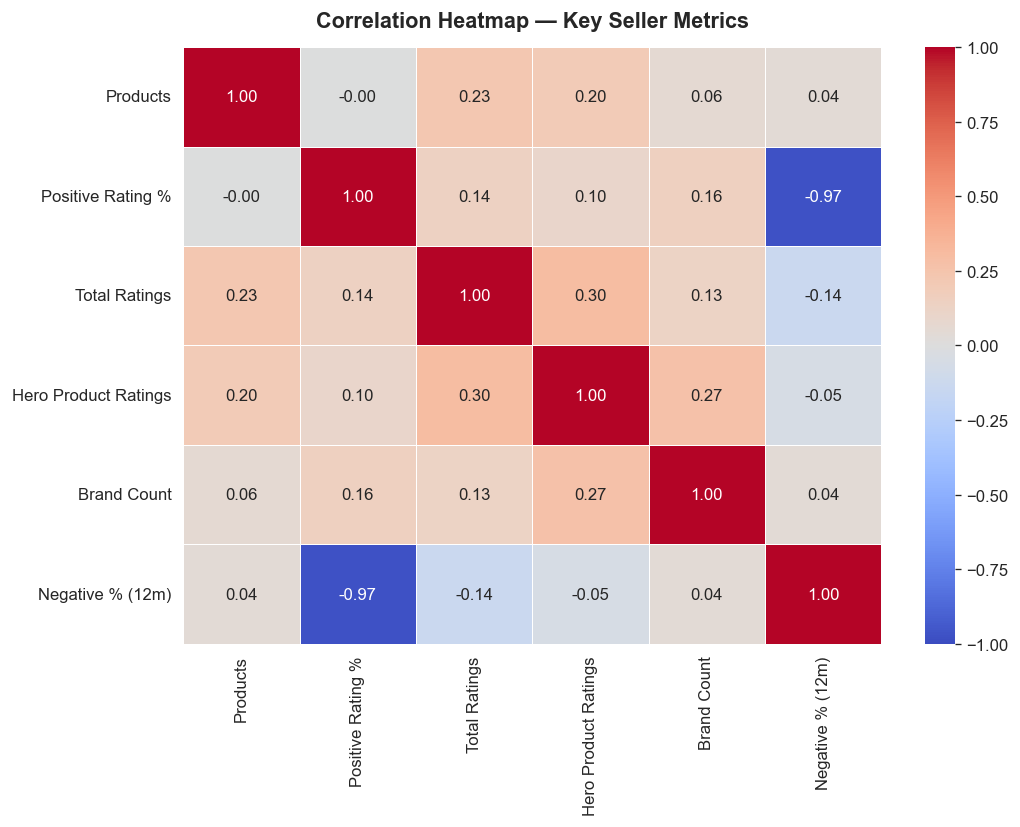


📌 Key correlations:
  Positive Rating % ↔ Negative % (12m): -0.97


In [23]:
corr_cols = [
    'product_count', 'positive_rating in percentage',
    'total_ratings given', 'avg_hero_products',
    'Count of seller brands',
    'Max % of negative seller ratings - last 12 months'
]
corr_matrix = df[corr_cols].corr()

# Rename for display
rename_map = {
    'product_count': 'Products',
    'positive_rating in percentage': 'Positive Rating %',
    'total_ratings given': 'Total Ratings',
    'avg_hero_products': 'Hero Product Ratings',
    'Count of seller brands': 'Brand Count',
    'Max % of negative seller ratings - last 12 months': 'Negative % (12m)'
}
corr_matrix.rename(columns=rename_map, index=rename_map, inplace=True)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Correlation Heatmap — Key Seller Metrics', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("\n📌 Key correlations:")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.3:
            print(f"  {corr_matrix.index[i]} ↔ {corr_matrix.columns[j]}: {val:.2f}")

### 4.7 High-Risk Sellers — High Sales but High Negative Ratings

High-risk sellers (popular but with negative ratings): 101


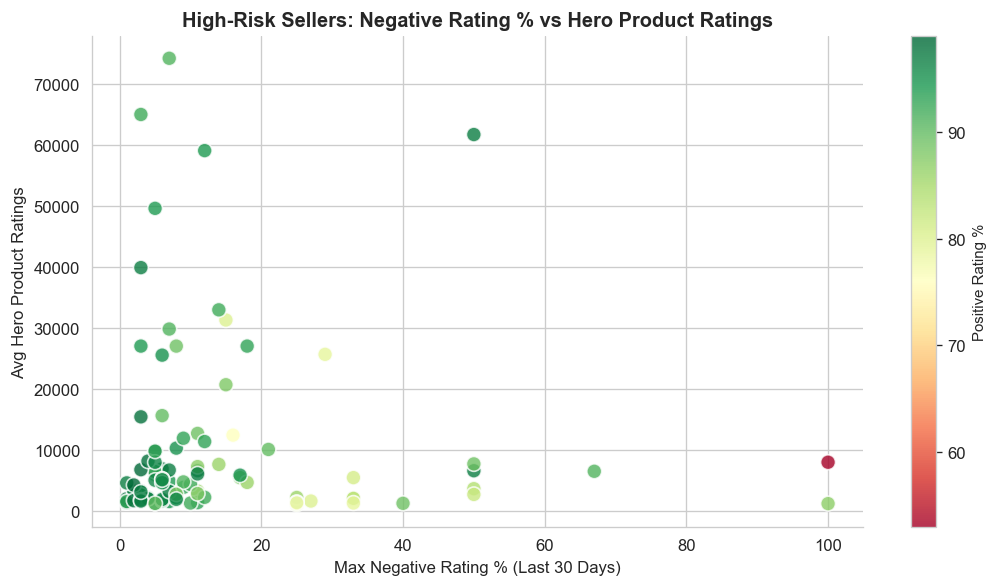

In [24]:
high_risk = df[
    (df['avg_hero_products'] > 1000) &
    (df['Max % of negative seller ratings - last 30 days'] > 0)
].copy()

print(f"High-risk sellers (popular but with negative ratings): {len(high_risk)}")

if len(high_risk) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    scatter = ax.scatter(
        high_risk['Max % of negative seller ratings - last 30 days'],
        high_risk['avg_hero_products'],
        c=high_risk['positive_rating in percentage'],
        cmap='RdYlGn', s=80, alpha=0.8, edgecolors='white'
    )
    cbar = plt.colorbar(scatter)
    cbar.set_label('Positive Rating %', fontsize=9)
    ax.set_title('High-Risk Sellers: Negative Rating % vs Hero Product Ratings',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Max Negative Rating % (Last 30 Days)', fontsize=10)
    ax.set_ylabel('Avg Hero Product Ratings', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

### 4.8 Seller Performance by Country

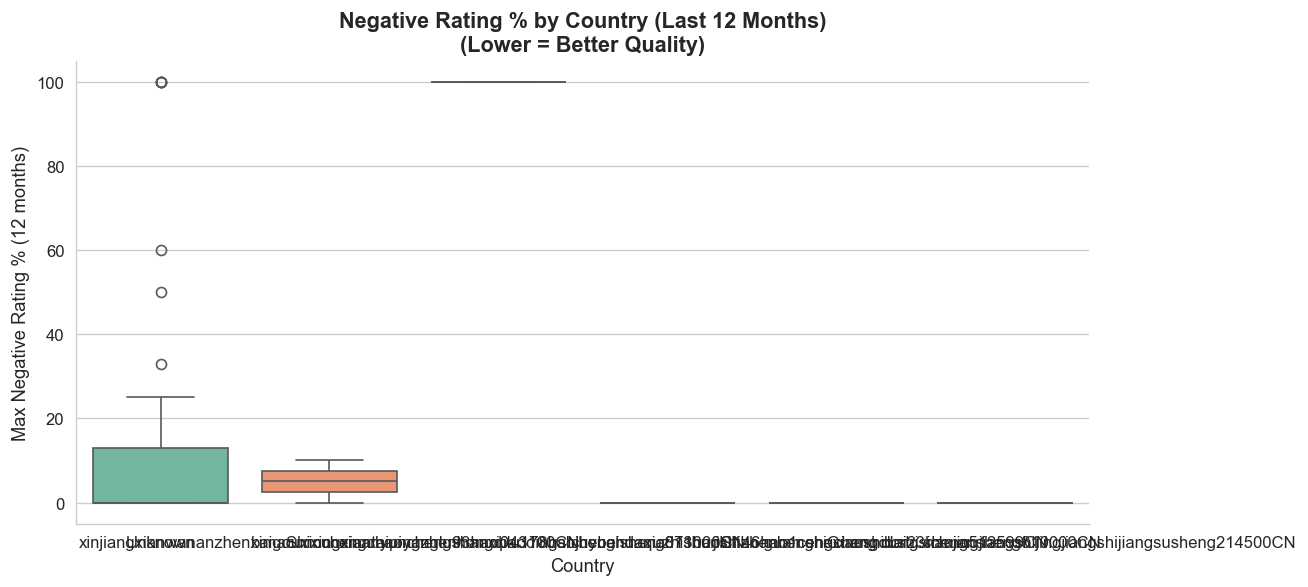

In [25]:
top_countries = df['Country'].value_counts().head(6).index
country_df = df[df['Country'].isin(top_countries)]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    x='Country',
    y='Max % of negative seller ratings - last 12 months',
    data=country_df,
    palette='Set2',
    ax=ax
)
ax.set_title('Negative Rating % by Country (Last 12 Months)\n(Lower = Better Quality)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Country', fontsize=11)
ax.set_ylabel('Max Negative Rating % (12 months)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 🏆 Step 5: Acquisition Scoring Model

We build a composite **Acquisition Score** to rank all sellers objectively.

### Scoring Framework

| Metric | Weight | Rationale |
|--------|--------|-----------|
| `positive_rating in percentage` | **30%** | Most direct quality signal — customers trust this seller |
| `total_ratings given` | **25%** | Proxy for sales volume — more ratings = more customers |
| `avg_hero_products` | **20%** | Flagship product strength — brand pulling power |
| `product_count` | **15%** | Catalog breadth — business scalability |
| `Count of seller brands` | **10%** | Portfolio diversification — reduces single-brand risk |

> **Negative rating penalty:** Sellers with any negative ratings in the last 30 days receive a 10% score reduction.

In [26]:
def normalize(series):
    """Min-max normalization to 0–1 range."""
    min_val, max_val = series.min(), series.max()
    if max_val == min_val:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - min_val) / (max_val - min_val)

# Work on rows with sufficient data
score_df = df.dropna(subset=[
    'positive_rating in percentage', 'total_ratings given',
    'avg_hero_products', 'product_count'
]).copy()

# Normalize each metric
score_df['rating_score']    = normalize(score_df['positive_rating in percentage'])
score_df['volume_score']    = normalize(score_df['total_ratings given'])
score_df['hero_score']      = normalize(score_df['avg_hero_products'])
score_df['product_score']   = normalize(score_df['product_count'])
score_df['brand_score']     = normalize(score_df['Count of seller brands'])

# Composite score
score_df['acquisition_score'] = (
    0.30 * score_df['rating_score'] +
    0.25 * score_df['volume_score'] +
    0.20 * score_df['hero_score'] +
    0.15 * score_df['product_score'] +
    0.10 * score_df['brand_score']
)

# Apply negative rating penalty (10% reduction)
penalty_col = 'Max % of negative seller ratings - last 30 days'
has_negative = score_df[penalty_col].fillna(0) > 0
score_df.loc[has_negative, 'acquisition_score'] *= 0.90

score_df['acquisition_score'] = score_df['acquisition_score'].round(4)

print(f"✅ Acquisition scores computed for {len(score_df)} sellers.")
print(f"\n   Score distribution:")
print(score_df['acquisition_score'].describe())

✅ Acquisition scores computed for 351 sellers.

   Score distribution:
count    351.000000
mean       0.333183
std        0.083973
min        0.080800
25%        0.271250
50%        0.337200
75%        0.388200
max        0.641900
Name: acquisition_score, dtype: float64


---
## 🎯 Step 6: Top Acquisition Targets

### Tier 1 — Premium Targets (Score ≥ 0.60)
These sellers have the strongest combination of volume, reputation, and product strength.

In [27]:
display_cols = [
    'acquisition_score',
    'positive_rating in percentage',
    'total_ratings given',
    'product_count',
    'avg_hero_products',
    'Count of seller brands',
    'Country',
    penalty_col
]

top_targets = score_df.sort_values('acquisition_score', ascending=False).head(15)

print("🏆 TOP 15 ACQUISITION TARGETS (Ranked by Score)")
print("=" * 80)
print(f"{'Rank':<6} {'Score':<8} {'Rating%':<10} {'Total Ratings':<15} {'Products':<10} {'Hero Avg':<10} {'Brands':<8} {'Country'}")
print("-" * 80)
for rank, (idx, row) in enumerate(top_targets.iterrows(), 1):
    neg_flag = '⚠️' if row[penalty_col] > 0 else '✅'
    print(f"{rank:<6} {row['acquisition_score']:<8.4f} "
          f"{row['positive_rating in percentage']:<10.0f} "
          f"{int(row['total_ratings given']):<15} "
          f"{int(row['product_count']):<10} "
          f"{row['avg_hero_products']:<10.0f} "
          f"{int(row['Count of seller brands']):<8} "
          f"{row['Country']} {neg_flag}")

print("\n✅ = No negative ratings in last 30 days  |  ⚠️ = Some negative ratings (penalized)")

🏆 TOP 15 ACQUISITION TARGETS (Ranked by Score)
Rank   Score    Rating%    Total Ratings   Products   Hero Avg   Brands   Country
--------------------------------------------------------------------------------
1      0.6419   94         6086            4000       49598      15       Emil-Von-Behring Straße 2AltripRheinland Pfalz67122DE ⚠️
2      0.6376   89         7242            40000      26996      16       Bauhofstr.24Lampertheim68623DE ⚠️
3      0.5905   94         7465            60000      520        13       N.T.HK ⚠️
4      0.5879   91         5150            50000      29796      15       itenga GmbHAm Umspannwerk 2Illingen66557DE ⚠️
5      0.5768   91         288             100000     74223      14       1249 S DIAMOND BAR BOULLEVARD UNIT 61DIAMOND BARCA91765US ⚠️
6      0.5547   97         3416            7000       39878      16       Dieselstr.4Kerpen50170DE ⚠️
7      0.5532   92         159             10000      62286      16       MARUYAMACHO28-1 8th FloorSHIBUYAKUTO

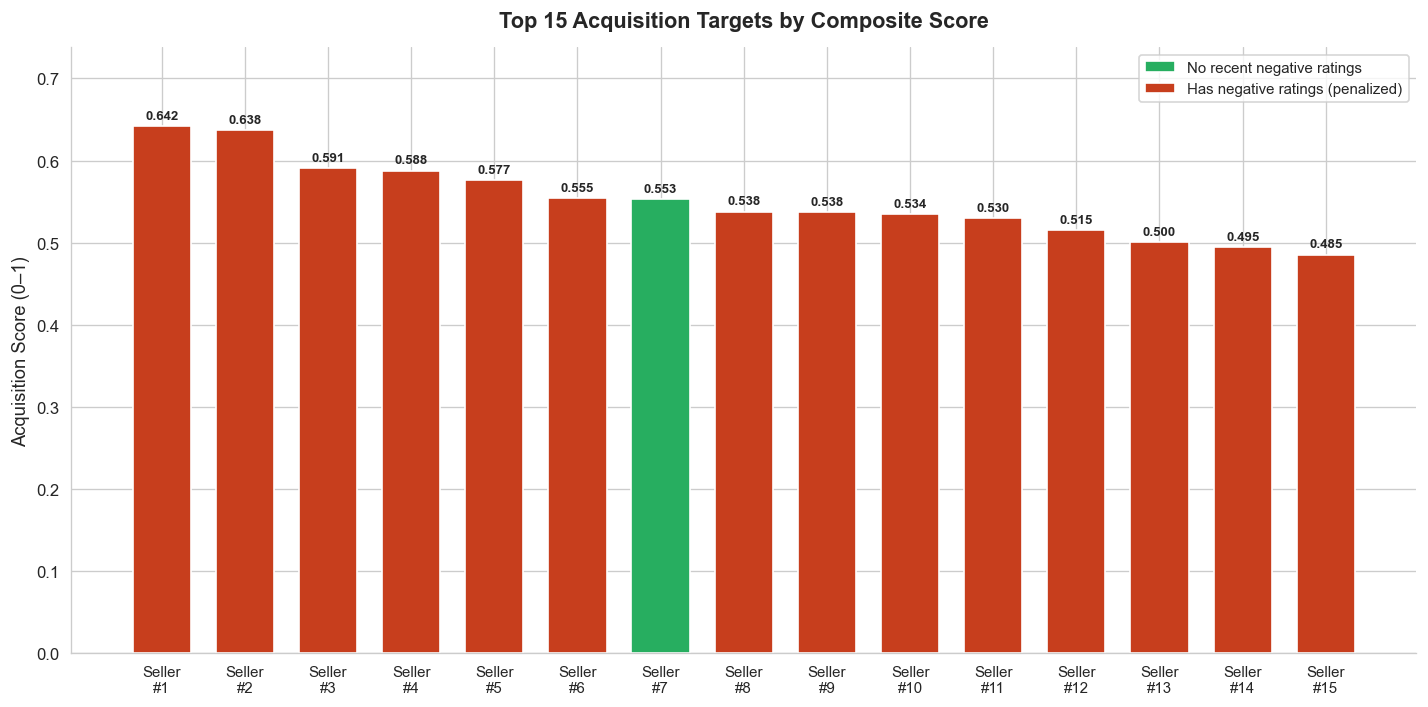

In [28]:
# Visualize top 15 sellers by acquisition score
fig, ax = plt.subplots(figsize=(12, 6))

top15 = top_targets.head(15)
colors = ['#27AE60' if top15.iloc[i][penalty_col] == 0 else '#C73E1D'
          for i in range(len(top15))]

bars = ax.bar(range(len(top15)), top15['acquisition_score'], color=colors, edgecolor='white', width=0.7)

for i, (bar, val) in enumerate(zip(bars, top15['acquisition_score'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(range(len(top15)))
ax.set_xticklabels([f'Seller\n#{i+1}' for i in range(len(top15))], fontsize=9)
ax.set_title('Top 15 Acquisition Targets by Composite Score',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Acquisition Score (0–1)', fontsize=11)
ax.set_ylim(0, top15['acquisition_score'].max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27AE60', label='No recent negative ratings'),
    Patch(facecolor='#C73E1D', label='Has negative ratings (penalized)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

### 6.1 Perfect Sellers — 100% Positive, Zero Negatives

In [29]:
perfect = score_df[
    (score_df['negative_count'] == 0) |
    (score_df[penalty_col] == 0)
].copy()

print(f"Sellers with ZERO negative ratings: {len(perfect)}")

# Among perfect sellers, find those with strong volume + brands
top_perfect = perfect[
    (perfect['Count of seller brands'] > 5) &
    (perfect['product_count'] > 500) &
    (perfect['total_ratings given'] > 200) &
    (perfect['avg_hero_products'] > 500)
].sort_values('acquisition_score', ascending=False)

print(f"\n🌟 IDEAL ACQUISITION TARGETS (Perfect rating + Strong Volume):")
print(f"   Count: {len(top_perfect)}")
print("\n" + top_perfect[display_cols].to_string())

Sellers with ZERO negative ratings: 178

🌟 IDEAL ACQUISITION TARGETS (Perfect rating + Strong Volume):
   Count: 24

      acquisition_score  positive_rating in percentage  total_ratings given  product_count  avg_hero_products  Count of seller brands                                                                                                        Country  Max % of negative seller ratings - last 30 days
1395             0.4372                           97.0                910.0         2000.0             5991.0                      16                                                                      Gundelsheimer Str 1414Theilenhofen91741DE                                                0
661              0.4353                           95.0                215.0         5000.0            18008.0                      15                                                               Hohenstaufenring59KölnNordrhein-Westfalen50674DE                                                0
9